# Detecting edges

## Basic setup

In [32]:
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/projects/image-to-black-white/src")

import cv2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.lines

## Loading images

In [2]:
nazwy_plikow = [
    # "../out/image1.jpg",
    # "../out/image2.jpg",
    # "../out/image3.jpg",
    # "../out/image4.jpg",
    # "../out/image5.jpg",
    # "../out/image7.jpg",
    "../out/image8.jpg",
    "../out/image9.jpg",
    "../out/image10.jpg",
    "../out/image11.jpg"
]

images = []

for file_name in nazwy_plikow:
    img = cv2.imread(file_name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

## Displaying loaded images

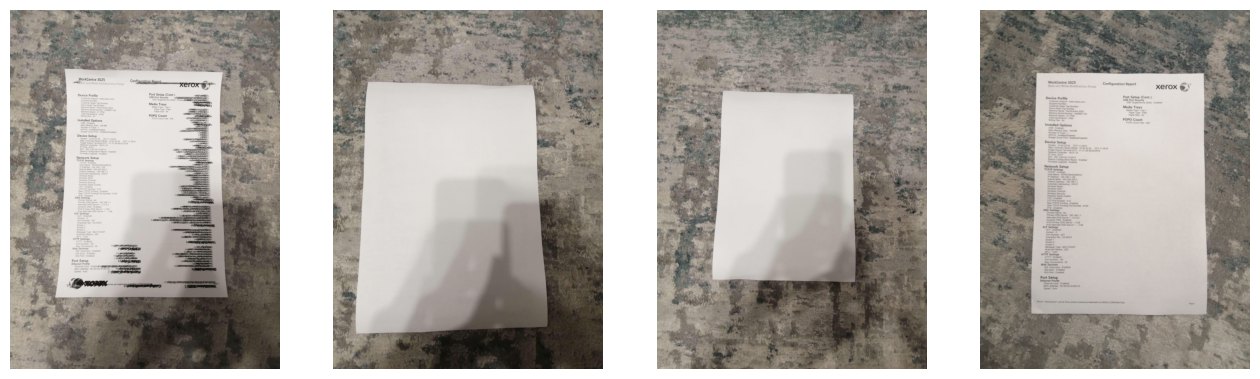

In [3]:
fig = plt.figure(figsize=(16, 8))

for i, img in enumerate(images):
    fig.add_subplot(1, len(images), i + 1)
    
    # plt.imshow(img)
    plt.axis('off')
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    
plt.show()

## Functions definitions

In [27]:
def resize_image(img_cp, max_width, max_height): 
    height, width, _ = img_cp.shape
    
    x_scale = max_width / width
    y_scale = max_height / height
    scale = max(x_scale, y_scale)

    img_cp = cv2.resize(img_cp, (int(width * scale), int(height * scale)))
    return img_cp

def get_hough_lines(edges_cp):
    lines = cv2.HoughLines(edges_cp, 1, np.pi / 180, 100,
                          30, 0, 0, 0, np.pi)
    return lines

def get_image_with_lines(image_cp, lines_cp, max_cnt = 1000):
    print(lines_cp.size)
    
    for rho, theta in lines_cp[0:max_cnt, 0]:
        line_length = 10000
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + line_length*(-b))
        y1 = int(y0 + line_length*(a))
        x2 = int(x0 - line_length*(-b))
        y2 = int(y0 - line_length*(a))
        cv2.line(image_cp, (x1,y1), (x2,y2), (255,0,255), 5)

    return image_cp

def modifyImage_HoughLines(image_cp):
    image_cp = cv2.GaussianBlur(image_cp, (3, 3), 1)
    
    edges = cv2.Canny(image_cp, 150, 200, apertureSize=3)
    
    lines = get_hough_lines(edges)

    # print(len(lines))

    return get_image_with_lines(image_cp, lines)

## Setting main image

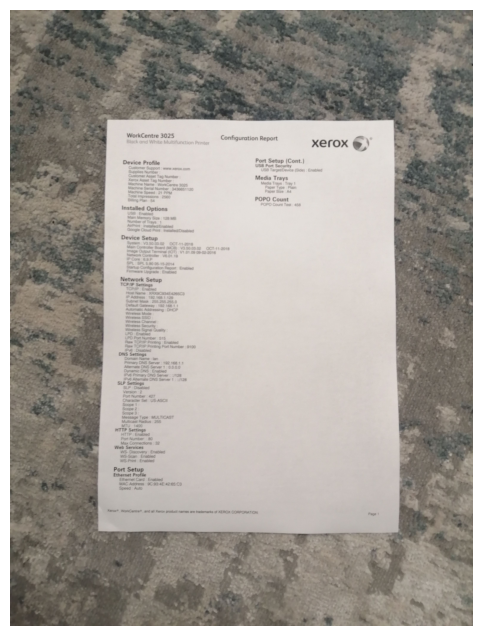

In [5]:
fig = plt.figure(figsize=(16, 8))

main_image = images[3].copy()
main_image = resize_image(main_image, 1024, 1024)

plt.axis('off')
plt.imshow(img)

plt.show()

## HoughLines test

56


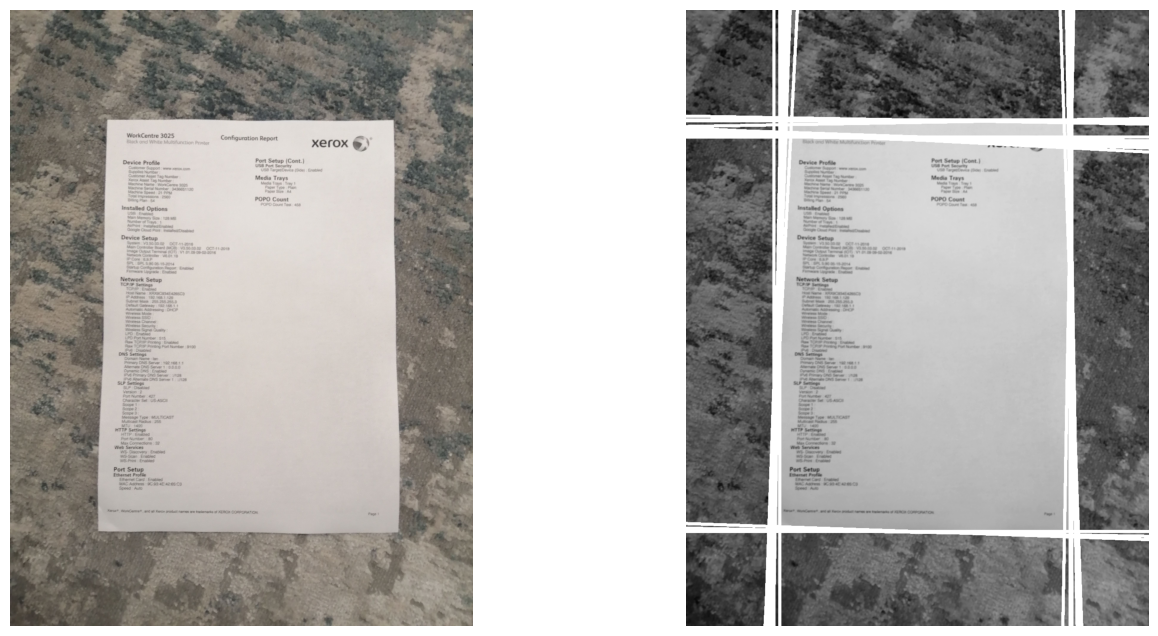

In [6]:
fig = plt.figure(figsize=(16, 8))

img = main_image.copy()
fig.add_subplot(1, 2, 1)
plt.axis('off')
plt.imshow(img)

new_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
new_img = modifyImage_HoughLines(new_img)
fig.add_subplot(1, 2, 2)
plt.axis('off')
plt.imshow(new_img, cmap=plt.get_cmap('gray'))

plt.show()

## Modifying image

In [7]:
def edit_image(new_img):
    hor_edges = np.zeros((height, width)) # horizontal edges
    ver_edges = np.zeros((height, width)) # vertical edges
    
    hor_edges_th = np.zeros((height, width)) # horizontal edges (thicker)
    ver_edges_th = np.zeros((height, width)) # vertical edges (thicker)
    
    for row in range(height):
    
        try:
            f = new_img[row, :].tolist().index(255)
            l = width - new_img[row, :].tolist()[::-1].index(255)
            
            hor_edges[row, [f, l]] = 255
    
            hor_edges_th[(row - 2):(row + 2), (f - 2):(f + 2)] = 255
            hor_edges_th[(row - 2):(row + 2), (l - 2):(l + 2)] = 255
            
        except:
            f = -1
            l = -1
    
        # print(f, l)
    
    for col in range(width):
        
        try:
            f = new_img[:, col].tolist().index(255)
            l = height - new_img[:, col].tolist()[::-1].index(255)
            
            ver_edges[[f, l], col] = 255
            
            ver_edges_th[(f - 2):(f + 2), (col - 2):(col + 2)] = 255
            ver_edges_th[(l - 2):(l + 2), (col - 2):(col + 2)] = 255
            
        except:
            f = -1
            l = -1
    
        # print(f, l)
    
    new_img = np.clip(ver_edges + hor_edges, 0, 255).astype(np.uint8)
    new_img_th = np.clip(ver_edges_th + hor_edges_th, 0, 255).astype(np.uint8)

    return [new_img, new_img_th]

[array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)]


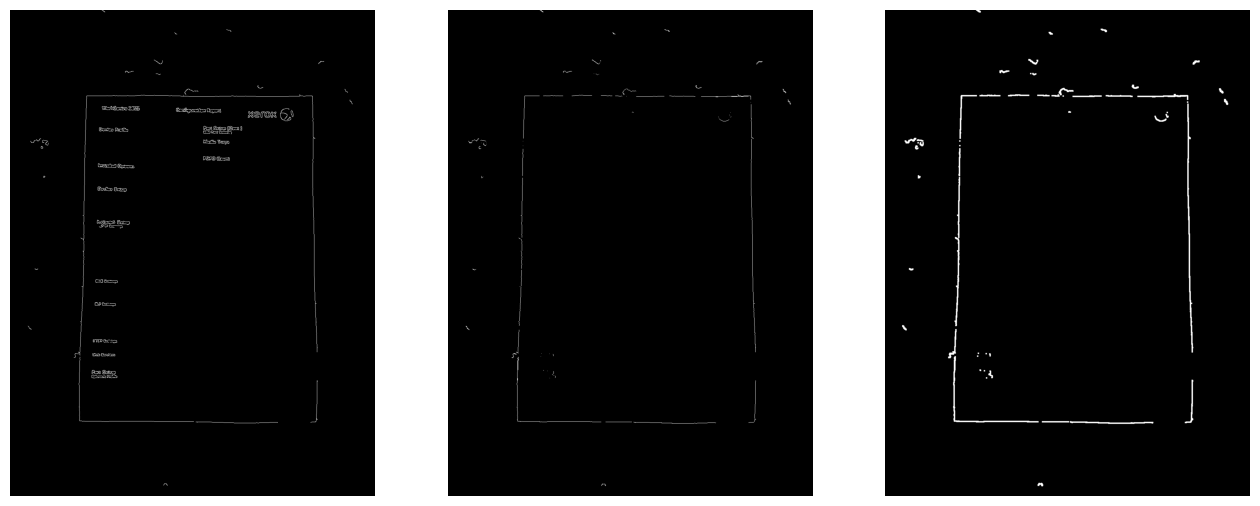

In [8]:
fig = plt.figure(figsize=(16, 8))
# fig = plt.figure(figsize=(16, 16))

img = main_image.copy()
new_img = cv2.GaussianBlur(img, (7, 7), 1)
new_img = cv2.cvtColor(new_img, cv2.COLOR_BGR2GRAY)
new_img = cv2.Canny(new_img, 100, 200, apertureSize=3)

fig.add_subplot(1, 3, 1)
plt.axis("off")
plt.imshow(new_img, cmap=plt.get_cmap('gray'))

height, width = new_img.shape

# raise SystemExit("test")

lst = edit_image(new_img)
print(lst)
new_img = lst[0]
new_img_th = lst[1]

fig.add_subplot(1, 3, 2)
plt.axis("off")
plt.imshow(new_img, cmap=plt.get_cmap('gray'))

fig.add_subplot(1, 3, 3)
plt.axis("off")
plt.imshow(new_img_th, cmap=plt.get_cmap('gray'))

plt.show()

36


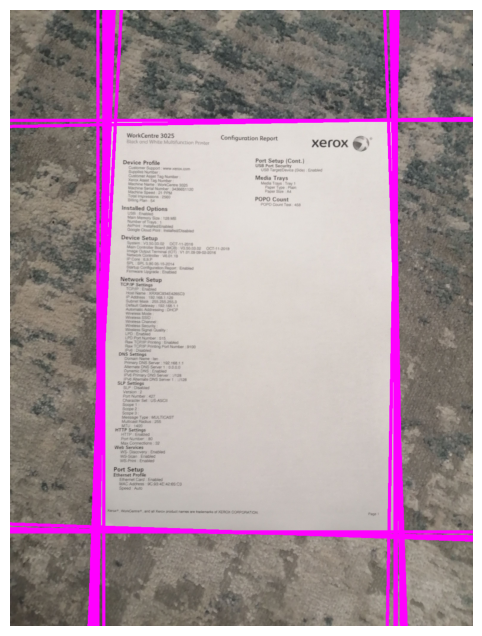

In [122]:
plt.figure(figsize=(16, 8))

lines = get_hough_lines(new_img)
img_with_edges = get_image_with_lines(main_image.copy(), lines)
plt.axis('off')
plt.imshow(img_with_edges, cmap=plt.get_cmap('gray'))

plt.show()

[[[-8.4200000e+02  3.1241393e+00]]

 [[ 2.1700000e+02  1.7453292e-02]]

 [[ 1.1490000e+03  1.5882496e+00]]

 [[ 1.1560000e+03  1.5707964e+00]]

 [[-8.2800000e+02  3.1066861e+00]]

 [[ 2.3000000e+02  3.4906585e-02]]

 [[ 2.4400000e+02  1.5707964e+00]]

 [[-8.4500000e+02  3.1241393e+00]]

 [[ 2.1300000e+02  1.7453292e-02]]

 [[ 8.5100000e+02  0.0000000e+00]]

 [[ 2.0700000e+02  0.0000000e+00]]

 [[ 2.5800000e+02  1.5533431e+00]]

 [[ 8.5400000e+02  0.0000000e+00]]

 [[ 2.2300000e+02  3.4906585e-02]]

 [[ 2.4500000e+02  5.2359879e-02]]

 [[ 1.1380000e+03  1.6057029e+00]]

 [[ 1.9400000e+02  0.0000000e+00]]

 [[ 8.5800000e+02  1.7453292e-02]]]


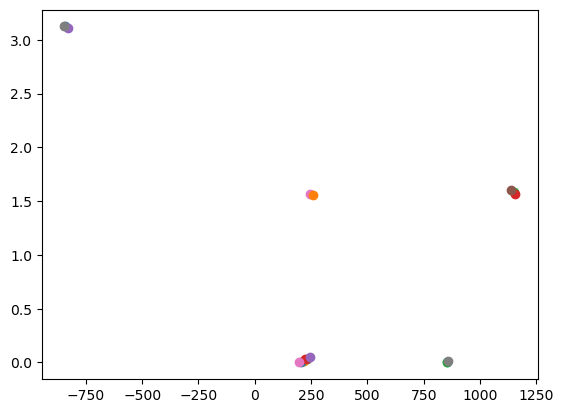

In [123]:
print(lines)

lines_cp = np.transpose(lines)

plt.plot(lines_cp[0], lines_cp[1], 'o')

# plt.show()

## Detecting lines similar

In [131]:
def similar_lines(l1, l2):
    smth_diff = abs(l1[0] - l2[0])
    angle_diff = abs(l1[1] - l2[1])
    angle_diff = min(angle_diff, abs(angle_diff - 2 * np.pi))
    if angle_diff > (np.pi / 2):
        smth_diff = abs(l1[0] + l2[0])
        angle_diff = abs(angle_diff - np.pi)

    # print("angle_diff:", angle_diff)
    # print("smth diff:", abs(l1[0] - l2[0]))
    
    if smth_diff > 100:
        return False
    
    if angle_diff > (np.pi / 4):
        return False
    
    return True

def print_similar_lines(lines):
    group_arr = [-1] * (lines.size // 2)

    for index, (line_group, line) in enumerate(zip(group_arr, lines[:, 0])):
        # print(index, line_group, line)
        
        if group_arr[index] == -1:
            group_arr[index] = max(group_arr) + 1
        
        for index_2, (tmp_group, tmp_line) in enumerate(zip(group_arr[index + 1:], lines[index + 1:, 0])):
            if tmp_group != -1:
                continue
                
            if similar_lines(line, tmp_line) == True:
                # print(lines[index, 0], "similar with", lines[index + 1 + index_2, 0])
                group_arr[index + 1 + index_2] = group_arr[index]

    return group_arr

In [132]:
group_arr = print_similar_lines(lines)
print(group_arr)

[0, 1, 2, 2, 0, 1, 3, 0, 1, 0, 1, 3, 0, 1, 1, 2, 1, 0]


In [143]:
res_arr = []
for target in range(4):
    indexes = [index for index, val in enumerate(group_arr) if target == val]
    print(target, "-", lines[indexes])
    res_arr.append(lines[indexes])

0 - [[[-8.4200000e+02  3.1241393e+00]]

 [[-8.2800000e+02  3.1066861e+00]]

 [[-8.4500000e+02  3.1241393e+00]]

 [[ 8.5100000e+02  0.0000000e+00]]

 [[ 8.5400000e+02  0.0000000e+00]]

 [[ 8.5800000e+02  1.7453292e-02]]]
1 - [[[2.1700000e+02 1.7453292e-02]]

 [[2.3000000e+02 3.4906585e-02]]

 [[2.1300000e+02 1.7453292e-02]]

 [[2.0700000e+02 0.0000000e+00]]

 [[2.2300000e+02 3.4906585e-02]]

 [[2.4500000e+02 5.2359879e-02]]

 [[1.9400000e+02 0.0000000e+00]]]
2 - [[[1149.           1.5882496]]

 [[1156.           1.5707964]]

 [[1138.           1.6057029]]]
3 - [[[244.          1.5707964]]

 [[258.          1.553343 ]]]


[[[-8.4200000e+02  3.1241393e+00]]

 [[-8.2800000e+02  3.1066861e+00]]

 [[-8.4500000e+02  3.1241393e+00]]

 [[ 8.5100000e+02  0.0000000e+00]]

 [[ 8.5400000e+02  0.0000000e+00]]

 [[ 8.5800000e+02  1.7453292e-02]]]
[[[2.1700000e+02 1.7453292e-02]]

 [[2.3000000e+02 3.4906585e-02]]

 [[2.1300000e+02 1.7453292e-02]]

 [[2.0700000e+02 0.0000000e+00]]

 [[2.2300000e+02 3.4906585e-02]]

 [[2.4500000e+02 5.2359879e-02]]

 [[1.9400000e+02 0.0000000e+00]]]
[[[1149.           1.5882496]]

 [[1156.           1.5707964]]

 [[1138.           1.6057029]]]
[[[244.          1.5707964]]

 [[258.          1.553343 ]]]


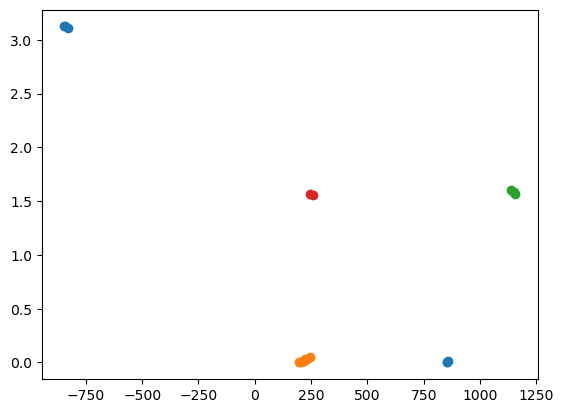

In [148]:
for x in res_arr:
    print(x)
    plt.plot(x[:, 0, 0], x[:, 0, 1], 'o')

plt.show()